In [1]:
# =========================================
# 1️⃣ IMPORTS
# =========================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor

# =========================================
# 2️⃣ LOAD DATA
# =========================================
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values("date_time").reset_index(drop=True)

# =========================================
# 3️⃣ BASIC CLEANING
# =========================================
df = df.drop_duplicates()

df['rain_1h'] = df['rain_1h'].fillna(0)
df['snow_1h'] = df['snow_1h'].fillna(0)
df['clouds_all'] = df['clouds_all'].fillna(df['clouds_all'].median())

# =========================================
# 4️⃣ FEATURE ENGINEERING
# =========================================

# ---- Time Features
df['hour'] = df['date_time'].dt.hour
df['dayofweek'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['dayofyear'] = df['date_time'].dt.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# ---- Cyclical Encoding
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['dow_sin'] = np.sin(2*np.pi*df['dayofweek']/7)
df['dow_cos'] = np.cos(2*np.pi*df['dayofweek']/7)

# ---- Holiday Encoding
df['is_holiday'] = (df['holiday'] != 'None').astype(int)

# ---- Weather Encoding
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

# =========================================
# 5️⃣ ADVANCED LAG FEATURES
# =========================================

for lag in [1,2,3,6,12,24,48,72]:
    df[f'lag_{lag}'] = df['traffic_volume'].shift(lag)

for window in [6,12,24]:
    df[f'rolling_mean_{window}'] = df['traffic_volume'].rolling(window).mean()
    df[f'rolling_std_{window}'] = df['traffic_volume'].rolling(window).std()

df = df.dropna()

# =========================================
# 6️⃣ TARGET TRANSFORMATION (IMPORTANT)
# =========================================
# Log transform reduces skew
df['traffic_volume_log'] = np.log1p(df['traffic_volume'])

# =========================================
# 7️⃣ DEFINE FEATURES
# =========================================
drop_cols = ['date_time','traffic_volume','traffic_volume_log',
             'holiday','weather_description']

features = [col for col in df.columns if col not in drop_cols]

X = df[features]
y = df['traffic_volume_log']

# =========================================
# 8️⃣ TIME-SERIES SPLIT
# =========================================
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

# =========================================
# 9️⃣ STRONG XGBOOST MODEL
# =========================================
xgb = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.3,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# =========================================
# 🔟 OPTIONAL STACKING (EXTREME BOOST)
# =========================================
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

stack_model = StackingRegressor(
    estimators=[('xgb', xgb), ('rf', rf)],
    final_estimator=Ridge()
)

stack_model.fit(X_train, y_train)

# =========================================
# 1️⃣1️⃣ PREDICTION
# =========================================
pred_log = stack_model.predict(X_test)

# Reverse log transform
pred = np.expm1(pred_log)
y_actual = np.expm1(y_test)

# =========================================
# 1️⃣2️⃣ EVALUATION
# =========================================
print("FINAL MAE:", mean_absolute_error(y_actual, pred))
print("FINAL R2:", r2_score(y_actual, pred))

FINAL MAE: 144.84250606974732
FINAL R2: 0.595239338906742


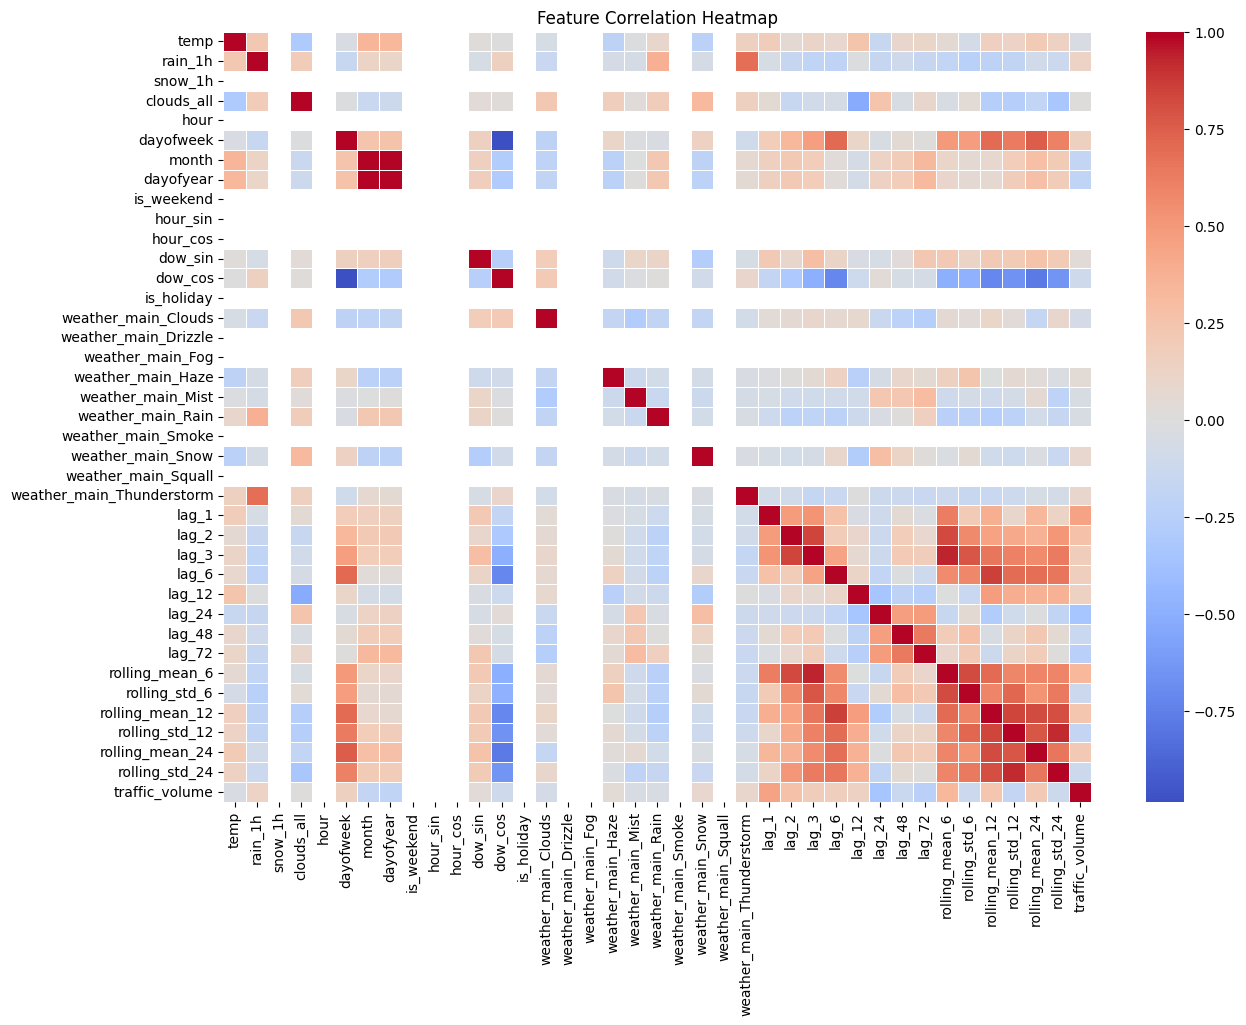

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

# Correlation matrix of features + target
corr_matrix = df[features + ['traffic_volume']].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [2]:
stack_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('xgb', ...), ('rf', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


In [3]:
import joblib

joblib.dump(stack_model, "traffic_model.pkl")
joblib.dump(features, "model_features.pkl")

print("Model saved successfully!")

Model saved successfully!


In [4]:
# =========================================
# REAL-TIME PREDICTOR FUNCTION
# =========================================
import joblib
import numpy as np

# Load saved model
model = joblib.load("traffic_model.pkl")
features = joblib.load("model_features.pkl")

def predict_traffic(input_df):
    input_df = input_df[features]
    pred_log = model.predict(input_df)
    return np.expm1(pred_log)[0]

In [ ]:
def predict_traffic(input_data):
    pred_log = stack_model.predict(input_data)[0]
    return np.expm1(pred_log)   # reverse log transform

In [5]:
# =========================================
# COORDINATED SIGNAL LOGIC
# =========================================

def calculate_green_time(predicted_traffic):
    if predicted_traffic < 200:
        return 30
    elif predicted_traffic < 500:
        return 45
    else:
        return 70


def coordinate_signals(j1_pred, j2_pred, j3_pred):

    j1_time = calculate_green_time(j1_pred)
    j2_time = calculate_green_time(j2_pred)
    j3_time = calculate_green_time(j3_pred)

    # Simple corridor logic:
    # If first junction is heavy, slightly boost next signal
    if j1_pred > 600:
        j2_time += 10

    if j2_pred > 600:
        j3_time += 10

    return j1_time, j2_time, j3_time

In [6]:
# =========================================
# REAL-TIME CORRIDOR SIMULATION
# =========================================
import time

print("Starting Corridor Simulation...\n")

start_index = len(X) - 50

for i in range(start_index, start_index + 20):

    j1_input = X.iloc[[i]]
    j2_input = X.iloc[[i+1]]
    j3_input = X.iloc[[i+2]]

    j1_pred = predict_traffic(j1_input)
    j2_pred = predict_traffic(j2_input)
    j3_pred = predict_traffic(j3_input)

    j1_time, j2_time, j3_time = coordinate_signals(j1_pred, j2_pred, j3_pred)

    print(f"Time Step {i}")
    print("Traffic:", round(j1_pred), round(j2_pred), round(j3_pred))
    print("Green Time:", j1_time, j2_time, j3_time)
    print("-"*40)

    time.sleep(1)

Starting Corridor Simulation...

Time Step 11
Traffic: 553 923 749
Green Time: 70 70 80
----------------------------------------
Time Step 12
Traffic: 923 749 1312
Green Time: 70 80 80
----------------------------------------
Time Step 13
Traffic: 749 1312 532
Green Time: 70 80 80
----------------------------------------
Time Step 14
Traffic: 1312 532 633
Green Time: 70 80 70
----------------------------------------
Time Step 15
Traffic: 532 633 988
Green Time: 70 70 80
----------------------------------------
Time Step 16
Traffic: 633 988 991
Green Time: 70 80 80
----------------------------------------
Time Step 17
Traffic: 988 991 638
Green Time: 70 80 80
----------------------------------------
Time Step 18
Traffic: 991 638 976
Green Time: 70 80 80
----------------------------------------
Time Step 19
Traffic: 638 976 559
Green Time: 70 80 80
----------------------------------------
Time Step 20
Traffic: 976 559 690
Green Time: 70 80 70
----------------------------------------
Time

In [7]:
# =========================================
# PERFORMANCE COMPARISON
# =========================================

fixed_time = 45

def estimate_wait_time(volume, green_time):
    red_time = 120 - green_time   # assume 120 sec cycle
    return volume * red_time

ai_wait = estimate_wait_time(j2_pred, j2_time)
fixed_wait = estimate_wait_time(j2_pred, fixed_time)

improvement = ((fixed_wait - ai_wait) / fixed_wait) * 100

print("Waiting Time Improvement: {:.2f}%".format(improvement))

Waiting Time Improvement: 46.67%
